# YouTube views of brainrot videos
Working notebook, self-contained: it reads only `data/external/youtube_views.parquet` (numbers per scraped video, no titles or ids) and `fonts/`. The table is built by `python -m src.yt_views` from the scrape (`src/yt_run.py`, `src/yt_dataset.py`); the numbers quoted below are in `docs/numbers_youtube_views.md`.

### Q1. Did the views of brainrot videos on YouTube change over time?
**Why we asked:** Reddit shows what people write; YouTube views show what they watch, a second trace of the media diet behind the slang (H2).

**What we did:** From the scraped YouTube search sample we took the 7,131 videos whose title matches the brainrot lexicon (the Roblox game "Steal a Brainrot" left out) and drew the density of their views for each publish year from 2019 to 2026, on a log scale: left the total views on 5 October 2026, right the views per day since publishing (total views divided by age). The sample is what YouTube's search showed for brainrot-slang queries sorted by views and by date: a ranked sample, not all videos.

**Result:** Median views per day by publish year: 22 (2019), 24 (2020), 4 (2021), 1 (2022), 154 (2023), 63 (2024), 1,299 (2025) and 1,752 (2026), from 59, 93, 145, 172, 891, 1,325, 2,251 and 2,176 videos. Median total views: 56,975, 55,084, 6,877, 820, 179,937, 53,392, 525,702 and 36,594. Looking only at the videos the views-sorted search found, the medians per day are 62 for 2024, 2,291 for 2025 and 2,652 for 2026.

**Interpretation:** The curves move right in two steps: the number of videos and their views per day rise in 2023, and views per day jump again for 2025 and 2026. Total views of 2026 videos are low only because they are new. Two cautions: the number of videos found is not a rate, and a video's lifetime average per day is highest while it is young (its early burst is not yet spread over years), so part of the 2025-26 jump is age, not attention.

**Next question:** When were the most-viewed brainrot videos published (Q2)?

In [1]:
import pathlib
H4_ROOT = pathlib.Path.cwd()
if not (H4_ROOT / "data").exists():  # opened from subfolder
    H4_ROOT = H4_ROOT.parent
import warnings; warnings.filterwarnings("ignore")

In [2]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import Polygon
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

In [3]:
import textwrap
from contextlib import contextmanager
from matplotlib import font_manager as fm
from matplotlib.colors import LinearSegmentedColormap

# H4 look: jost, no frame, soft gray axes
# hack: ttfs share one family name, so one FontEntry per weight
H4_INK, H4_MUTED, H4_FAINT, H4_GRID = "#1c1c1c", "#6f6f6f", "#9b9b9b", "#e6e6e6"
H4_SUB = {"teenagers": "#E8575F", "memes": "#A82E3C", "books": "#C46FBC", "explainlikeimfive": "#8A2B87",
          "todayilearned": "#E9A23B", "nosurf": "#10A38E"}  # danylo's hues
H4_GROUP = {"short_form": "#C9404B", "long_form": "#8A2B87", "baseline": "#E9A23B", "reflective": "#10A38E"}
H4_GROUP_LABEL = {"short_form": "r/memes + r/teenagers", "long_form": "r/books + r/explainlikeimfive",
                  "baseline": "r/todayilearned", "reflective": "r/nosurf"}
H4_RAMP_COLORS = ["#003f5c", "#594e90", "#bc4c96", "#ff5f66", "#ffa600"]
H4_RAMP = LinearSegmentedColormap.from_list("h4_ramp", H4_RAMP_COLORS)
H4_TERMS = {"rizz": "#ffa600", "skibidi": "#bc4c96", "gyatt": "#594e90", "brain rot": "#003f5c", "tung tung": "#ff5f66", "mewing": "#7a9cb0"}
_FONTS_DONE = []


def h4_text_color(color):
    return {"#E9A23B": "#B87A14", "#ffa600": "#B87300", "#10A38E": "#0A7566", "#7a9cb0": "#4E7388"}.get(color, color)


def register_jost():
    if _FONTS_DONE:
        return
    for w, f in {300: "Light", 400: "Medium", 500: "Medium", 600: "SemiBold", 700: "Bold", 800: "ExtraBold"}.items():  # 400 = regular
        path = H4_ROOT / "fonts" / f"Jost-{f}.ttf"
        if path.exists():
            fm.fontManager.ttflist.append(fm.FontEntry(fname=str(path), name="Jost", style="normal", variant="normal",
                                                       weight=w, stretch="normal", size="scalable"))
    _FONTS_DONE.append(True)


@contextmanager
def h4_style():
    register_jost()
    rc = {"font.family": "Jost", "font.size": 11, "text.color": H4_INK, "axes.labelcolor": H4_FAINT, "axes.labelsize": 10,
          "axes.labelweight": 600, "xtick.color": H4_FAINT, "ytick.color": H4_FAINT, "xtick.labelsize": 10, "ytick.labelsize": 10,
          "xtick.major.size": 0, "ytick.major.size": 0, "axes.spines.top": False, "axes.spines.right": False,
          "axes.spines.left": False, "axes.spines.bottom": False, "axes.grid": True, "grid.color": H4_GRID, "grid.linewidth": 0.8,
          "axes.axisbelow": True, "axes.titlelocation": "left", "figure.facecolor": "white", "axes.facecolor": "white"}
    with plt.rc_context(rc):
        yield


def h4_title(fig, text, size=26):
    H = fig.get_figheight()
    fig.text(0.012, 1 - 0.14 / H, text.upper(), fontsize=size, fontweight=800, va="top", ha="left", color=H4_INK)
    return 1 - (0.14 + size / 72 * 1.25 + 0.22) / H  # returns plot-area top, fig fraction


def h4_foot(fig, text, width=185):
    fig.text(0.012, 0.012, textwrap.fill(text, width), fontsize=8.5, fontweight=300, color=H4_FAINT, va="bottom", ha="left")


def h4_legend(fig, entries, x_right=0.985, y_top=None, ncol=None, col_w=1.55):
    # entries: (label, color, style)
    from matplotlib.patches import Rectangle
    W, H = fig.get_size_inches()
    ncol = ncol or min(len(entries), 4)
    rows = -(-len(entries) // ncol)
    row_h, pad = 0.42, 0.18
    box_w, box_h = ncol * col_w + 2 * pad - 0.16, rows * row_h + 0.2
    y_top = (1 - 0.12 / H) if y_top is None else y_top
    lg = fig.add_axes([x_right - box_w / W, y_top - box_h / H, box_w / W, box_h / H])
    lg.set_xlim(0, box_w)
    lg.set_ylim(0, box_h)
    lg.axis("off")
    lg.add_patch(Rectangle((0.04, -0.04), box_w, box_h, facecolor="#eeeeee", edgecolor="none", clip_on=False, zorder=0))
    lg.add_patch(Rectangle((0, 0), box_w, box_h, facecolor="white", edgecolor="#d6d6d6", linewidth=1, clip_on=False, zorder=1))
    for i, (lab, col, style) in enumerate(entries):
        x0, y0 = pad + (i % ncol) * col_w, box_h - 0.15 - (i // ncol) * row_h
        lg.text(x0, y0, lab, fontsize=9.5, fontweight=700, color=H4_INK, va="top", ha="left", zorder=2)
        if style == "outline":
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, alpha=0.25, edgecolor=col, linewidth=1.2, zorder=2))
        elif style:
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, alpha=0.3, hatch=style, edgecolor=col, linewidth=0, zorder=2))
        else:
            lg.add_patch(Rectangle((x0, y0 - 0.3), col_w - 0.16, 0.11, facecolor=col, edgecolor="none", zorder=2))
    return lg


def h4_chips(ax, events, ypos=1.0, fontsize=9):
    import pandas as pd
    for date, label in events:
        ax.axvline(pd.Timestamp(date), color="#333", lw=0.9, ls=(0, (4, 3)), alpha=0.75, zorder=1)
        ax.annotate(label, (pd.Timestamp(date), ypos), xycoords=("data", "axes fraction"), xytext=(0, 4), textcoords="offset points",
                    ha="center", va="bottom", fontsize=fontsize, fontweight=600, color="#333",
                    bbox=dict(boxstyle="round,pad=0.25", fc="#f2f2f2", ec="none"), annotation_clip=False)


def h4_done(fig, finding, how):
    fig.h4_finding, fig.h4_how = finding, how
    return fig

**Brainrot-titled videos published in 2025 and 2026 get far more views per day (median 1,299 and 1,752) than those from 2019 to 2024 (median at most 154), in this search sample.**

*How to read: One curve per publish year: the more videos at a given number of views, the higher the curve; further right = more views. Left: total views on 5 Oct 2026 (older videos had longer to collect them). Right: views per day since publishing. Log scales, white tick = median.*

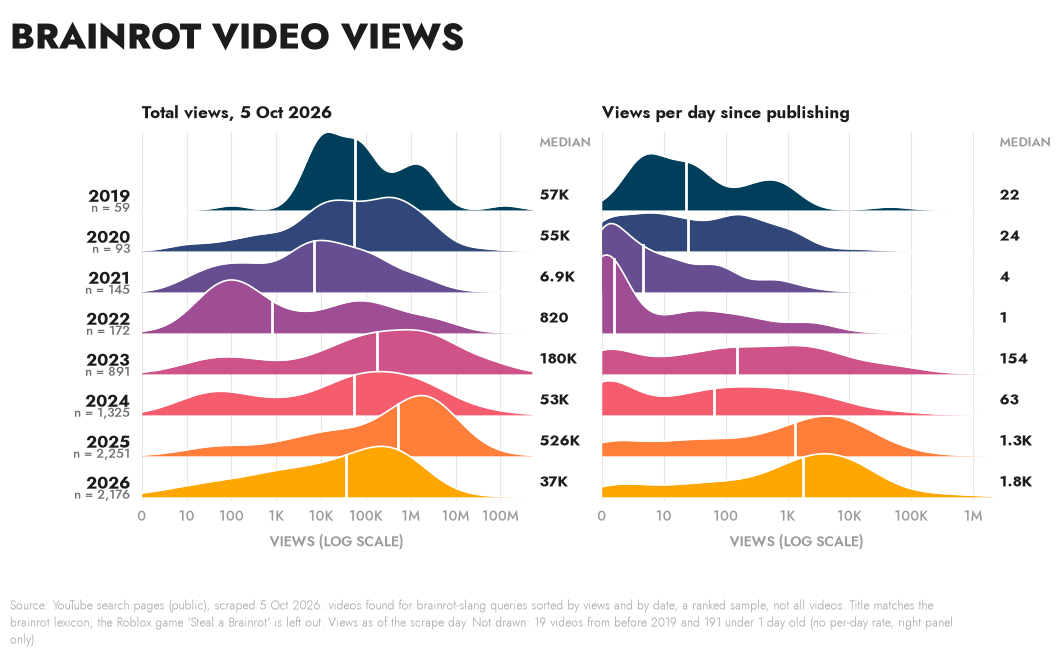

In [4]:
def compact(v):
    return f"{v / 1e6:.1f}M" if v >= 1e6 else f"{v / 1e3:.1f}K" if v >= 1e3 and v < 1e4 else f"{v / 1e3:.0f}K" if v >= 1e4 else f"{v:.0f}"


def views_density():
    v = pd.read_parquet(H4_ROOT / "data" / "external" / "youtube_views.parquet")
    b = v[v.br & ~v.game].assign(year=lambda x: x.published_at.dt.year)
    n_old, n_young = int((b.year < 2019).sum()), int(b.views_per_day.isna().sum())
    b = b[b.year >= 2019]
    years = sorted(b.year.unique())
    cols = [H4_RAMP(i / (len(years) - 1)) for i in range(len(years))]
    med = b.groupby("year").views_per_day.median()
    late, early = med[med.index >= years[-2]], med[med.index < years[-2]]
    finding = (f"Brainrot-titled videos published in {years[-2]} and {years[-1]} get far more views per day (median {late.iloc[0]:,.0f} and {late.iloc[1]:,.0f}) "
               f"than those from {years[0]} to {years[-3]} (median at most {early.max():,.0f}), in this search sample.")
    how = ("One curve per publish year: the more videos at a given number of views, the higher the curve; further right = more views. Left: total views "
           "on 5 Oct 2026 (older videos had longer to collect them). Right: views per day since publishing. Log scales, white tick = median.")
    panels = [("view_count", "Total views, 5 Oct 2026", 8.7), ("views_per_day", "Views per day since publishing", 6.3)]
    with h4_style():
        fig = plt.figure(figsize=(11, 6.6))
        top = (1 - h4_title(fig, "Brainrot video views")) * fig.get_figheight()
        W, H = fig.get_size_inches()
        axes = [fig.add_axes([x / W, 1.55 / H, 3.9 / W, (H - 1.55 - top - 0.55) / H]) for x in (1.45, 6.05)]
        for ax, (col, ttl, xmax) in zip(axes, panels):
            grid = np.linspace(0, xmax, 400)
            dens = {}
            for y in years:
                x = np.log10(1 + b.loc[b.year == y, col].dropna().to_numpy())
                dens[y] = gaussian_kde(x, bw_method=0.3)(grid)
            peak = max(d.max() for d in dens.values())
            for r, y in enumerate(years):                                      # oldest on top, newer rows drawn in front
                base, z = len(years) - 1 - r, 5 + 2 * r
                h = dens[y] / peak * 1.9
                ax.fill_between(grid, base, base + h, color=cols[r], lw=0, zorder=z)
                ax.plot(grid, base + h, color="white", lw=1.2, zorder=z + 1)
                m = np.log10(1 + b.loc[b.year == y, col].dropna().median())
                ax.plot([m, m], [base, base + np.interp(m, grid, h)], color="white", lw=2, zorder=z + 1)
                ax.text(1.02, base + 0.12, compact(b.loc[b.year == y, col].median()), transform=ax.get_yaxis_transform(), fontsize=10.5, fontweight=700,
                        color=H4_INK, ha="left", va="bottom")
                if ax is axes[0]:
                    ax.text(-0.03, base + 0.34, str(y), transform=ax.get_yaxis_transform(), fontsize=12, fontweight=700, color=H4_INK, ha="right", va="center")
                    ax.text(-0.03, base + 0.06, f"n = {int((b.year == y).sum()):,}", transform=ax.get_yaxis_transform(), fontsize=9, color=H4_MUTED,
                            ha="right", va="center")
            ax.text(1.02, len(years) + 0.55, "MEDIAN", transform=ax.get_yaxis_transform(), fontsize=9, fontweight=600, color=H4_FAINT, ha="left")
            ticks = np.arange(0, int(xmax) + 1)
            ax.set_xticks(ticks, ["0", "10", "100", "1K", "10K", "100K", "1M", "10M", "100M"][:len(ticks)])
            ax.set_xlim(0, xmax)
            ax.set_ylim(-0.1, len(years) + 0.9)
            ax.set_yticks([])
            ax.grid(axis="y", visible=False)
            ax.set_title(ttl, fontsize=12, fontweight=700, pad=10, color=H4_INK)
            ax.set_xlabel("VIEWS (LOG SCALE)")
        h4_foot(fig, "Source: YouTube search pages (public), scraped 5 Oct 2026: videos found for brainrot-slang queries sorted by views and by date, a ranked sample, "
                     "not all videos. Title matches the brainrot lexicon; the Roblox game 'Steal a Brainrot' is left out. Views as of the scrape day. "
                     f"Not drawn: {n_old} videos from before 2019 and {n_young} under 1 day old (no per-day rate, right panel only).")
        return h4_done(fig, finding, how)


fig = views_density()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()

### Q2. When were the most-viewed brainrot videos published?
**Why we asked:** Q1 compares the views of each publish year; this puts the whole period on one time axis and shows where the views sit.

**What we did:** The same brainrot-titled videos (Roblox game left out) published from January 2019, 7,112 of them. We smoothed their publish dates into one density curve over 2019 to 2026, weighting every video by its total views on 5 October 2026 (smoothing of about 1.5 months), and drew it as the share of all views per month. The gray curve is the same without weights: the share of videos found.

**Result:** Videos published in 2025 carry 43.7% of all views and videos from 2023 carry 31.6%; 2024 carries 16.5%, 2026 6.3% and 2019 to 2022 together 1.9%. The videos found are different: 31.7% are from 2025 and 30.6% from 2026, 12.5% from 2023. The views are not dominated by a few videos: the top 10 of the 7,112 hold 10.1% of the 17.0 billion views, the top 1% hold 35.2%.

**Against Reddit:** We also compared the YouTube series with the brainrot rate on Reddit, month by month from June 2022 to September 2026 (52 months, Spearman correlation; the p-value comes from shifted copies of the series, which keeps their trends). Views by publish month against the Reddit rate: r = +0.43 (p = 0.07) with the six subreddits pooled and r = +0.33 (p = 0.41) with r/memes + r/teenagers. The number of videos found gives r = +0.39 (p = 0.37) and +0.07 (p = 0.93). Month-to-month changes do not move together (r between -0.13 and +0.08, p of 0.45 or more). Reddit's rate peaks in November 2023, April 2024, December 2023, January 2025 and July 2024; the YouTube views peak in May, June and July 2025 and in July and August 2023.

**Interpretation:** There is no link to Reddit: none of the 8 tests is below p = 0.05 (the smallest is 0.07) and the peaks are months to a year apart. So the chart only describes the sample, where the views of the videos YouTube's search showed sit in time; it does not show waves of attention and does not support a connection between YouTube and Reddit brainrot. Videos from 2026 are low partly because they had less time to collect views, and the sample is ranked search results, not all of YouTube.

**Next question:** Would a source that is not a search sample, the trending lists, show a brainrot trend that matches Reddit? It holds few brainrot-titled videos (75 in the US file up to April 2024), so it may be too thin to say.

**In this search sample, brainrot-titled videos published in 2023 carry 32% of all views and those from 2025 carry 44%, while 2019 to 2022 together carry 2%.**

*How to read: The curve shows when the videos that collected the views were published: the higher it is at a date, the bigger the share of all views held by videos published around then (percent per month). Gray: the same for the number of videos found, which shows what the search sample contains. Colour only repeats the date.*

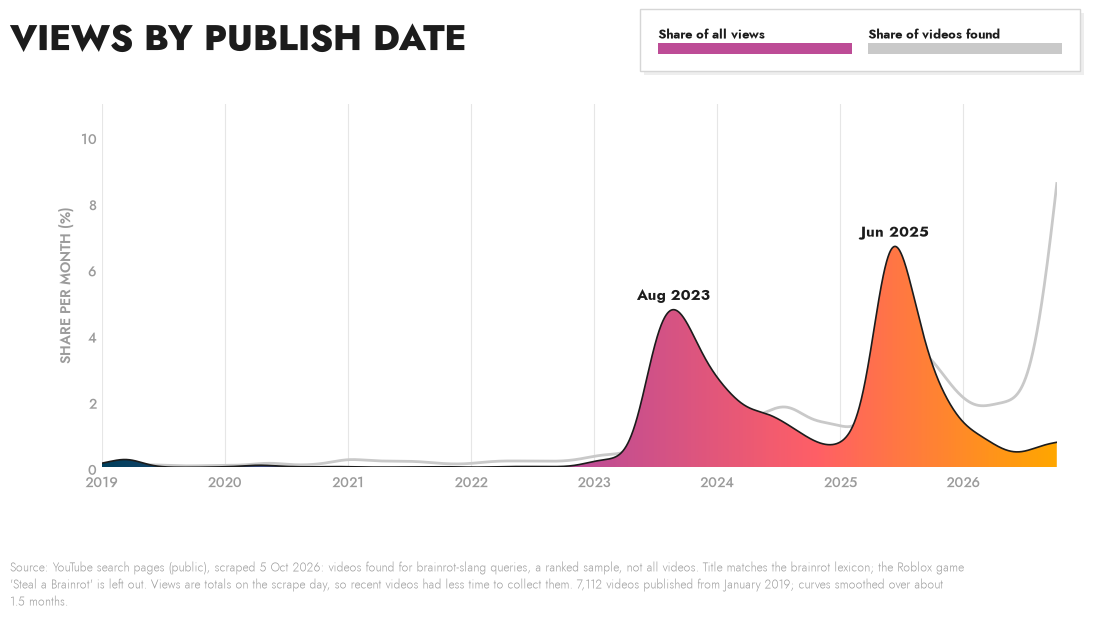

In [5]:
def views_by_date():
    v = pd.read_parquet(H4_ROOT / "data" / "external" / "youtube_views.parquet")
    b = v[v.br & ~v.game & (v.published_at >= "2019-01-01")].assign(year=lambda x: x.published_at.dt.year)
    t0 = pd.Timestamp("2019-01-01")
    days = pd.date_range(t0, b.published_at.max(), freq="D")
    d = (b.published_at - t0).dt.days.to_numpy()
    bw = 45  # days
    kern = np.exp(-0.5 * (np.arange(-4 * bw, 4 * bw + 1) / bw) ** 2)
    kern /= kern.sum()
    inside = np.convolve(np.ones(len(days)), kern, mode="same")  # edge correction: mass of the kernel inside the range

    def share(w):  # smoothed share per month, %
        h = np.bincount(d, weights=w / w.sum(), minlength=len(days))
        return np.convolve(h, kern, mode="same") / inside * 30.44 * 100

    views, videos = share(b.view_count.to_numpy(float)), share(np.ones(len(b)))
    pk, _ = find_peaks(views, prominence=0.25 * views.max())
    pk = pk[np.argsort(views[pk])[::-1][:2]]
    sv = b.groupby("year").view_count.sum() / b.view_count.sum() * 100
    top2 = sv.nlargest(2).sort_index()
    early = sv[sv.index < top2.index[0]].sum()
    finding = (f"In this search sample, brainrot-titled videos published in {top2.index[0]} carry {top2.iloc[0]:.0f}% of all views and those from "
               f"{top2.index[1]} carry {top2.iloc[1]:.0f}%, while {sv.index[0]} to {top2.index[0] - 1} together carry {early:.0f}%.")
    how = ("The curve shows when the videos that collected the views were published: the higher it is at a date, the bigger the share of all views held by videos "
           "published around then (percent per month). Gray: the same for the number of videos found, which shows what the search sample contains. "
           "Colour only repeats the date.")
    with h4_style():
        fig = plt.figure(figsize=(11, 6.2))
        top = (1 - h4_title(fig, "Views by publish date")) * fig.get_figheight()
        W, H = fig.get_size_inches()
        ax = fig.add_axes([1.05 / W, 1.5 / H, (W - 1.05 - 0.4) / W, (H - 1.5 - top - 0.25) / H])
        x = mdates.date2num(days)
        ax.plot(days, videos, color="#c9c9c9", lw=2, zorder=3)
        ax.plot(days, views, color=H4_INK, lw=1.2, zorder=6)
        poly = Polygon(np.column_stack([np.r_[x, x[::-1]], np.r_[views, np.zeros(len(x))]]), facecolor="none", edgecolor="none")
        ax.add_patch(poly)
        ymax = float(np.ceil(max(views.max(), videos.max()) * 1.18))
        im = ax.imshow(H4_RAMP(np.linspace(0, 1, 600))[None, :, :], extent=[x[0], x[-1], 0, ymax], aspect="auto", origin="lower", zorder=4, interpolation="bilinear")
        im.set_clip_path(poly)
        for i in pk:
            ax.annotate(f"{days[i]:%b %Y}", (days[i], views[i]), xytext=(0, 7), textcoords="offset points", ha="center", fontsize=10.5, fontweight=700, color=H4_INK, zorder=8)
        ax.set_xlim(days[0], days[-1])
        ax.set_ylim(0, ymax)
        ax.xaxis.set_major_locator(mdates.YearLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.grid(axis="y", visible=False)
        ax.set_ylabel("SHARE PER MONTH (%)")
        h4_legend(fig, [("Share of all views", H4_RAMP(0.5), None), ("Share of videos found", "#c9c9c9", None)], ncol=2, col_w=2.1)
        h4_foot(fig, "Source: YouTube search pages (public), scraped 5 Oct 2026: videos found for brainrot-slang queries, a ranked sample, not all videos. Title matches "
                     "the brainrot lexicon; the Roblox game 'Steal a Brainrot' is left out. Views are totals on the scrape day, so recent videos had less time to collect "
                     f"them. {len(b):,} videos published from January 2019; curves smoothed over about 1.5 months.")
        return h4_done(fig, finding, how)


fig = views_by_date()
display(Markdown(f"**{fig.h4_finding}**\n\n*How to read: {fig.h4_how}*"))
plt.show()